# 1.1 文字怎麼變成數字？


你傳給朋友「貓看狗」，朋友會直接讀出字義。但我們接下來寫的程式要做的是：看到「貓」後，猜下一個字是什麼。為了記錄它猜過哪些候選字，先要替每種字安排一個固定位置。想像圖書館替書貼上編號：編號幫我們找到書，並不替書解釋內容。文字的第一步也是這樣，先建立字與數字的對照，再談如何學會預測。

若你不熟悉 Python 的清單、字典與方括號，可以先讀 [W.2](https://birdhackor.github.io/tiny-perceptron-vlm/first-steps.html#W.2)；本節只會使用這些資料整理工具。把一種字指定給一個整數，這個整數叫 ID，也就是識別編號。例如約定「貓」對應 3，「狗」對應 1，只表示查到 3 時拿出「貓」。它不表示貓比狗大三倍，也不表示兩者意思相近。這份包含所有可用字的清單叫字表；字表中每個字都有唯一的位置。

我們用「貓看狗，狗看貓。」作例子。它有重複的字，但只需要替每種字編號一次。`set(text)` 把重複字收成一份不重複的集合；`sorted` 再把集合排成固定順序，因此同一段文字每次執行都會得到同一張表。Python 依每個字元在 Unicode（電腦統一記錄文字的編碼標準）中的數值排序，並非筆畫排序，順序本身沒有語言上的意義。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

In [2]:
text = "貓看狗，狗看貓。"
chars = sorted(set(text))
to_id = {}
for i, char in enumerate(chars):
    to_id[char] = i
ids = [to_id[char] for char in text]
restored = "".join(chars[i] for i in ids)
print(chars)
print(ids)
print(restored)
assert restored == text

['。', '狗', '看', '貓', '，']
[3, 2, 1, 4, 1, 2, 3, 0]
貓看狗，狗看貓。


輸入 `text` 是原句。`enumerate(chars)` 逐一提供「位置、字」這一對材料，像 `0, "。"`；迴圈把它存進字典 `to_id`，於是能由字找到位置。`[to_id[char] for char in text]` 是把迴圈寫在清單中的簡寫：按原句順序取出每個字，查出它的 ID，再收成清單。第一行輸出是 `['。', '狗', '看', '貓', '，']`，因此第二行是 `[3, 2, 1, 4, 1, 2, 3, 0]`。兩次「貓」都變成 3，標點也各有編號，沒有被丟掉。

下圖把原句、ID 清單與字表排在一起：上列是原句各字，下列是同一位置的 ID；橘色的兩張「貓」卡都連到 3，表示相同字每次使用相同編號。底下的字表是查找約定，讀到 3 就能逆向找到「貓」，讀到 0 就找到句號。箭頭只表示對應，沒有表示字義或數值大小。


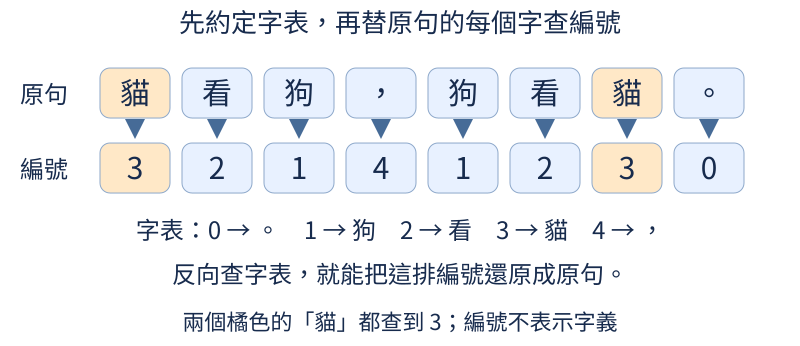

In [3]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/character_ids.svg")))

最後的 `chars[i]` 走相反方向，從 ID 查回字。`"".join(...)` 用空字串連接查回來的每個字，得到原句 `貓看狗，狗看貓。`。把文字換成 ID 叫編碼（encode），把 ID 換回文字叫解碼（decode）。`assert` 檢查兩個方向接起來能否還原原文；通過時它不印訊息。現在程式只完成可還原的記錄，尚未學會貓或狗的意義，也還沒有調整任何數字。

這套做法還有一個限制：字表中沒有的字無法查 ID。若編碼時改成「貓看鳥」，卻仍使用上面的 `to_id`，查「鳥」會出現 `KeyError`，因為字典找不到那個鍵。後面製作更實用的文字處理工具時會處理這個問題；眼前先使用字表涵蓋的小句子。

練習只把建立字表那行改成 `chars = sorted(set(text), reverse=True)`，其餘照跑。`reverse=True` 要求排序結果反過來，原本最後一種字會排到第一個位置。先預測原句的 ID 會變，還是還原的文字會變。結果應是編號改變、`restored` 仍相同，`assert` 仍通過。因為編碼表與解碼表一起更新了，這正好檢驗 ID 是一套約定，而不是字義本身。
